In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D

es = EarlyStopping(monitor = "val_loss", mode = "min", patience = 5)

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
EPOCHS = 100


In [16]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [17]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

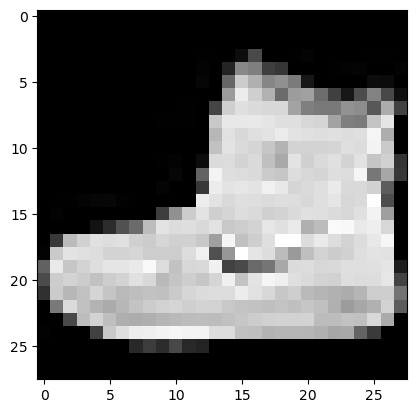

In [18]:
plt.imshow(x_train[0], cmap = "gray")

In [19]:
x_train[0].shape

(28, 28)

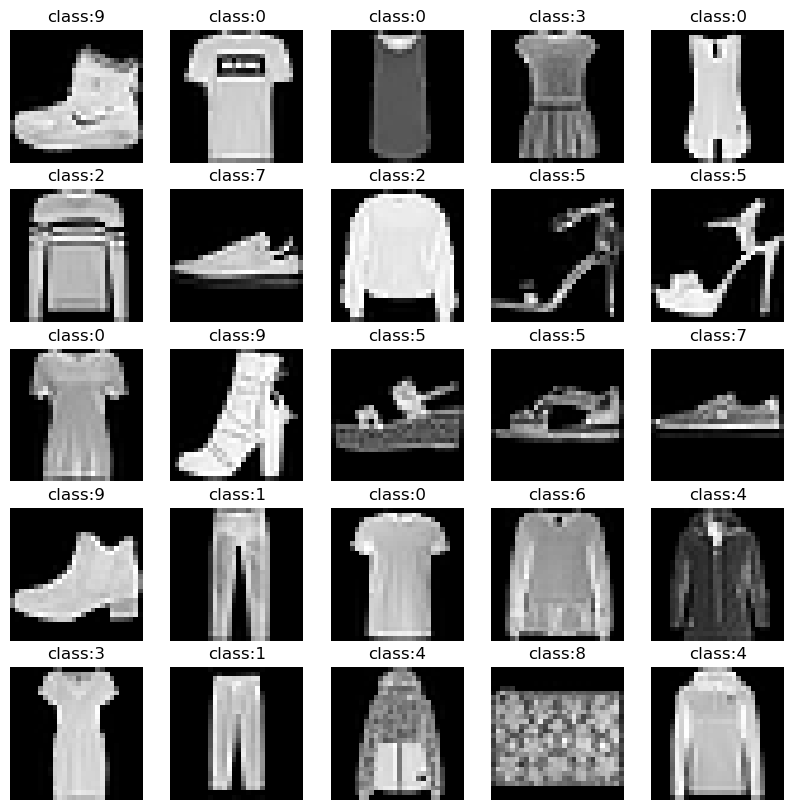

In [20]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap = "gray")
    plt.axis('off')
    plt.title("class:"+str(y_train[i]))

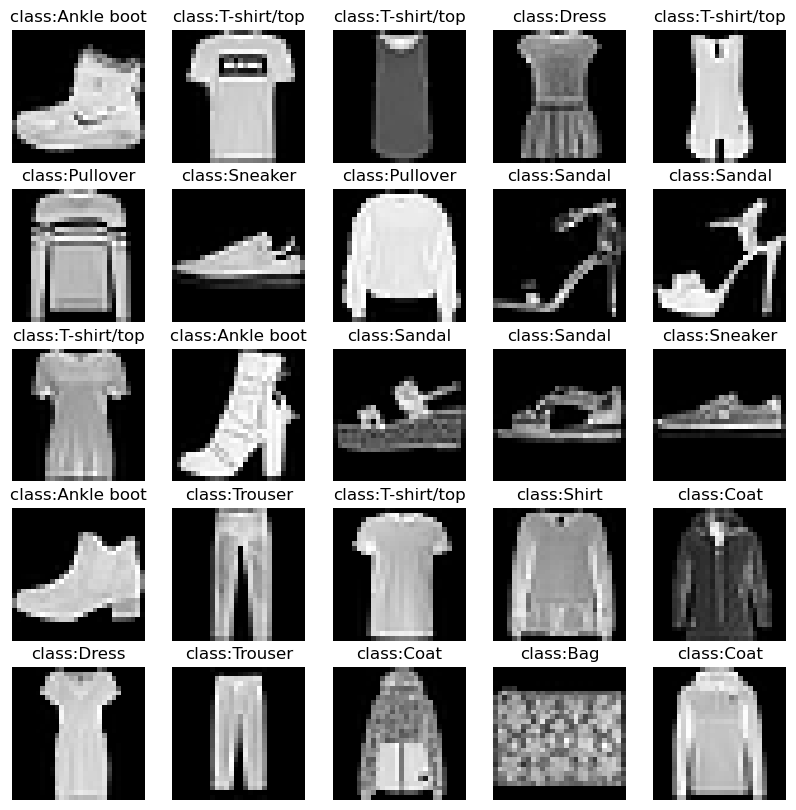

In [21]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_train[i], cmap = "gray")
    plt.axis('off')
    plt.title("class:"+str(class_names[y_train[i]]))

In [22]:
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

In [23]:
x_train.shape

(60000, 28, 28, 1)

In [24]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

model = Sequential()
model.add(Conv2D(filters = 4, kernel_size = (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.summary()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=EPOCHS, validation_data=(x_test, y_test), callbacks=[es])
hist = pd.DataFrame(history.history)

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 4)         40        
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 13, 13, 4)         0         
_________________________________________________________________
flatten_1 (Flatten)          (None, 676)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 10)                6770      
Total params: 6,810
Trainable params: 6,810
Non-trainable params: 0
_________________________________________________________________
Epoch 1/100
1875/1875 [==============================] - 5s 2ms/step - loss: 0.5621 - accuracy: 0.8072 - val_loss: 0.4574 - val_accuracy: 0.8349
Epoch 2/100
1875/1875 [==============================] - 4s 2ms/step - loss: 0.4122 - accuracy: 0.8561 - 

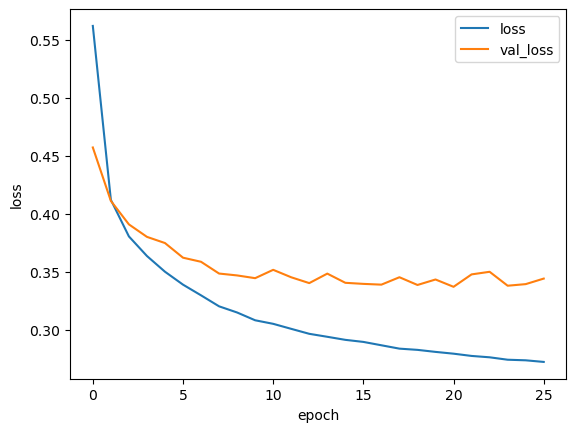

In [25]:
plt.plot(hist.loss, label = "loss")
plt.plot(hist.val_loss, label = "val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()

In [26]:
y_pred = model.predict(x_test)

[3.9119010e-07 1.3403557e-10 1.2670813e-06 9.0793186e-08 1.5940961e-07
 3.5750582e-03 1.2629716e-05 9.4114011e-03 5.2333955e-04 9.8647577e-01]


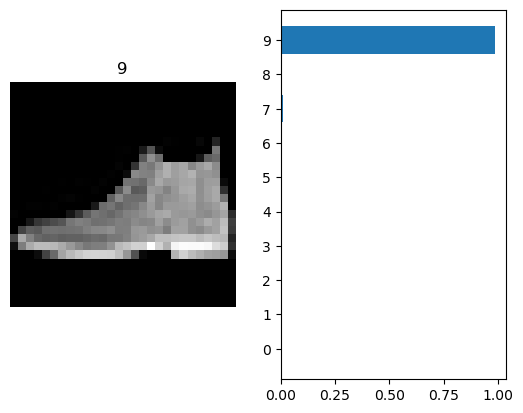

In [27]:
plt.subplot(1,2,1)
plt.imshow(x_test[0], cmap="gray")
plt.axis('off')
plt.title(y_test[0])

plt.subplot(1,2,2)
plt.barh(np.arange(10), y_pred[0])
plt.yticks(np.arange(10))
print(y_pred[0])

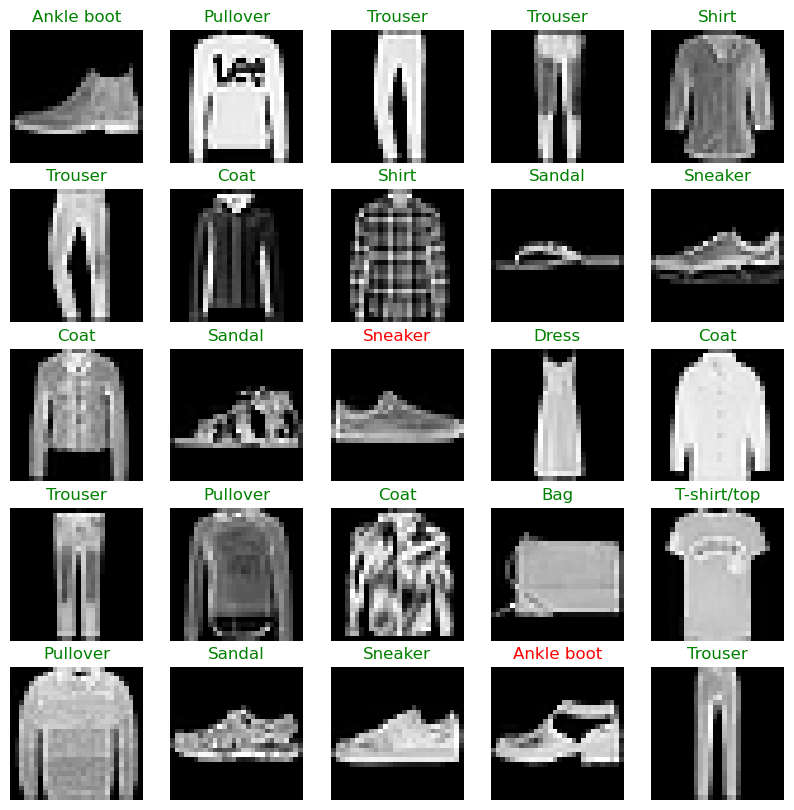

In [28]:
plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.axis('off')
    if np.argmax(y_pred[i]) == y_test[i]:
        plt.title(class_names[y_test[i]], color = 'green')
    else:
        plt.title(class_names[y_test[i]], color = 'red')